In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
from tms_risk.utils.data import get_all_behavior, get_tms_subjects, get_tms_conditions
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.contrib.itertools import product

bids_folder = Path('/data/ds-tmsrisk')
behavior = get_all_behavior(bids_folder)
tms_mapping = get_tms_conditions()

In [2]:
subjects = [f'{subject:02d}' for subject in get_tms_subjects(bids_folder)]


df = []
keys = []

for subject, spherical, use_prior in product(subjects, [False, True], [False, True]):
    dir_name = 'expected_uncertainty_spherical' if spherical else 'expected_uncertainty'
    dir_name += '.objective_prior' if use_prior else ''

    fn = bids_folder / 'derivatives' / dir_name / f'sub-{subject}' / 'func' / f'sub-{subject}_roi-NPCr2cm-cluster_desc-expected_error.tsv'

    try:
        df_sub = pd.read_csv(fn, sep='\t')
        df_sub['stimulation_condition'] = df_sub['session'].map(tms_mapping[subject])
        df_sub['model_type'] = spherical
        df_sub['use_prior'] = use_prior
        df.append(df_sub)
        keys.append(subject)

    except FileNotFoundError:
        print(f'File not found for subject {subject}, model_type: {spherical}, use_prior: {use_prior} skipping.')

df = pd.concat(df, keys=keys, names=['subject']).set_index(['stimulation_condition', 'model_type', 'use_prior'], append=True)


df = df[df['x'] >= 7 - 1e-6]

  0%|          | 0/140 [00:00<?, ?it/s]

File not found for subject 01, model_type: False, use_prior: True skipping.
File not found for subject 02, model_type: False, use_prior: True skipping.
File not found for subject 03, model_type: False, use_prior: True skipping.
File not found for subject 04, model_type: False, use_prior: True skipping.
File not found for subject 05, model_type: False, use_prior: True skipping.
File not found for subject 06, model_type: False, use_prior: True skipping.
File not found for subject 07, model_type: False, use_prior: True skipping.
File not found for subject 09, model_type: False, use_prior: True skipping.
File not found for subject 10, model_type: False, use_prior: True skipping.
File not found for subject 11, model_type: False, use_prior: True skipping.
File not found for subject 18, model_type: False, use_prior: True skipping.
File not found for subject 19, model_type: False, use_prior: True skipping.
File not found for subject 21, model_type: False, use_prior: True skipping.
File not fou

In [5]:
df['x'] = np.round(df['x'], 0)

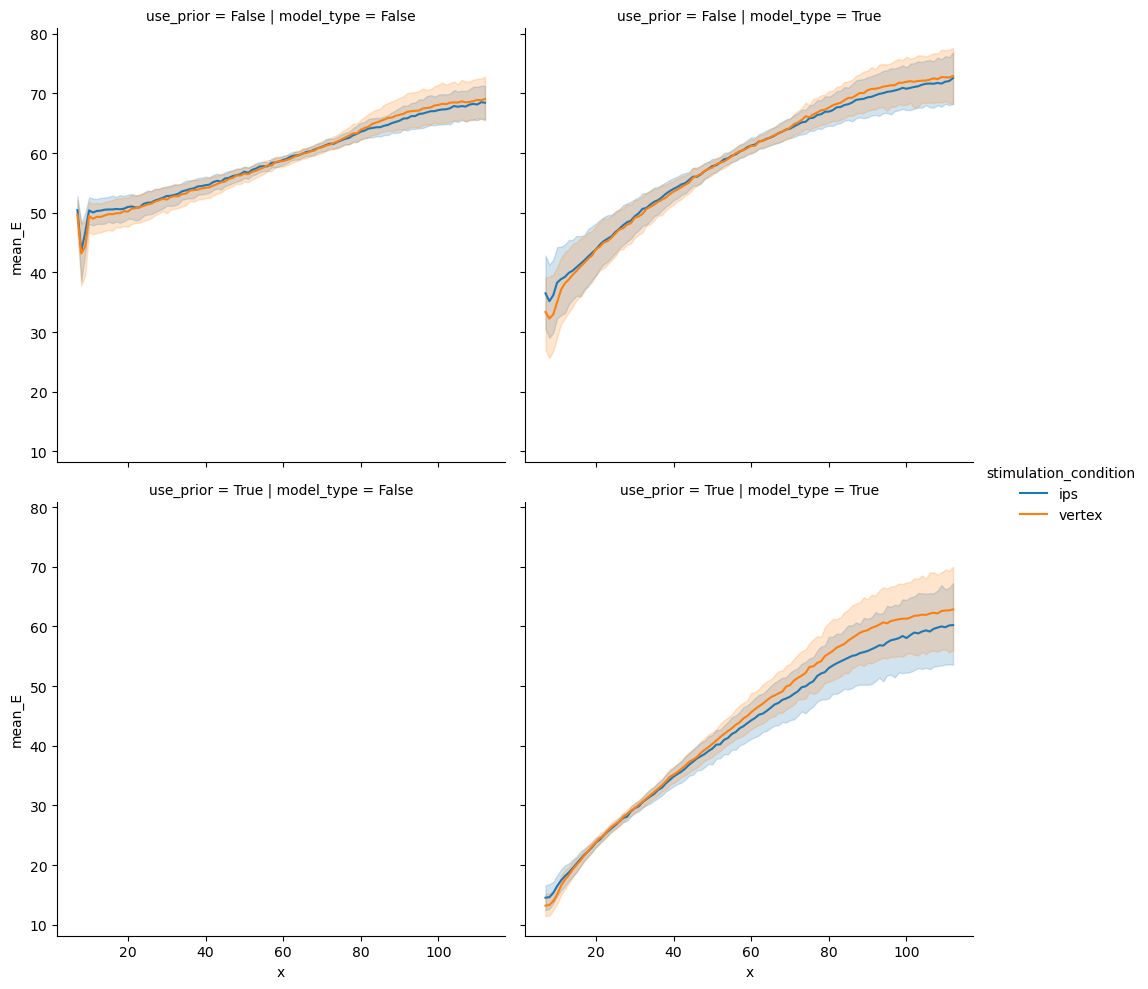

In [6]:
tmp = df.groupby(['subject', 'model_type', 'stimulation_condition', 'session','use_prior', 'x']).mean()

sns.relplot(x='x', y='mean_E', data=tmp.reset_index(), hue='stimulation_condition', kind='line', col='model_type', row='use_prior')

<Figure size 640x480 with 0 Axes>

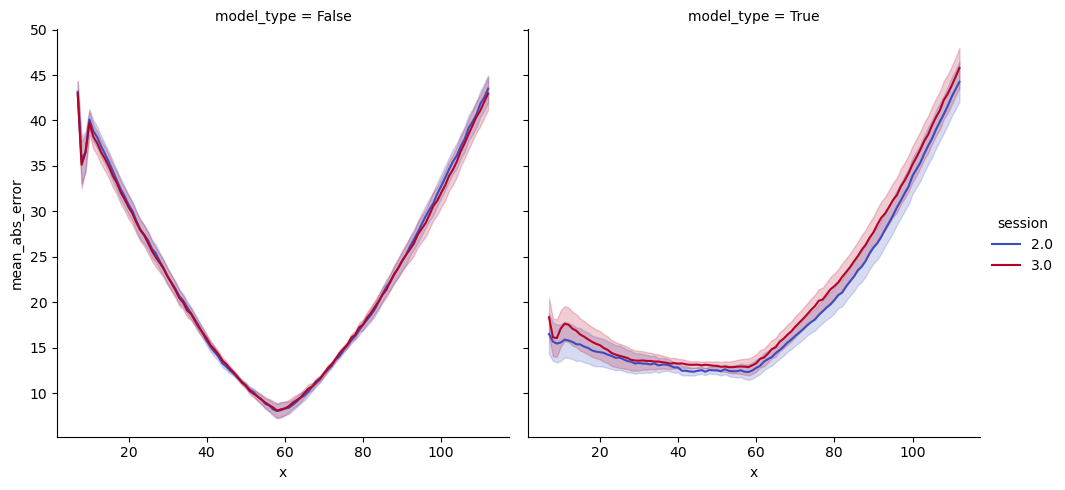

In [7]:
tmp = df.groupby(['subject', 'session', 'model_type', 'use_prior', 'x']).mean()


plt.figure()
sns.relplot(x='x', y='mean_abs_error', data=tmp.reset_index(), hue='session', kind='line', palette='coolwarm', errorbar='se', col='model_type')

<Figure size 640x480 with 0 Axes>

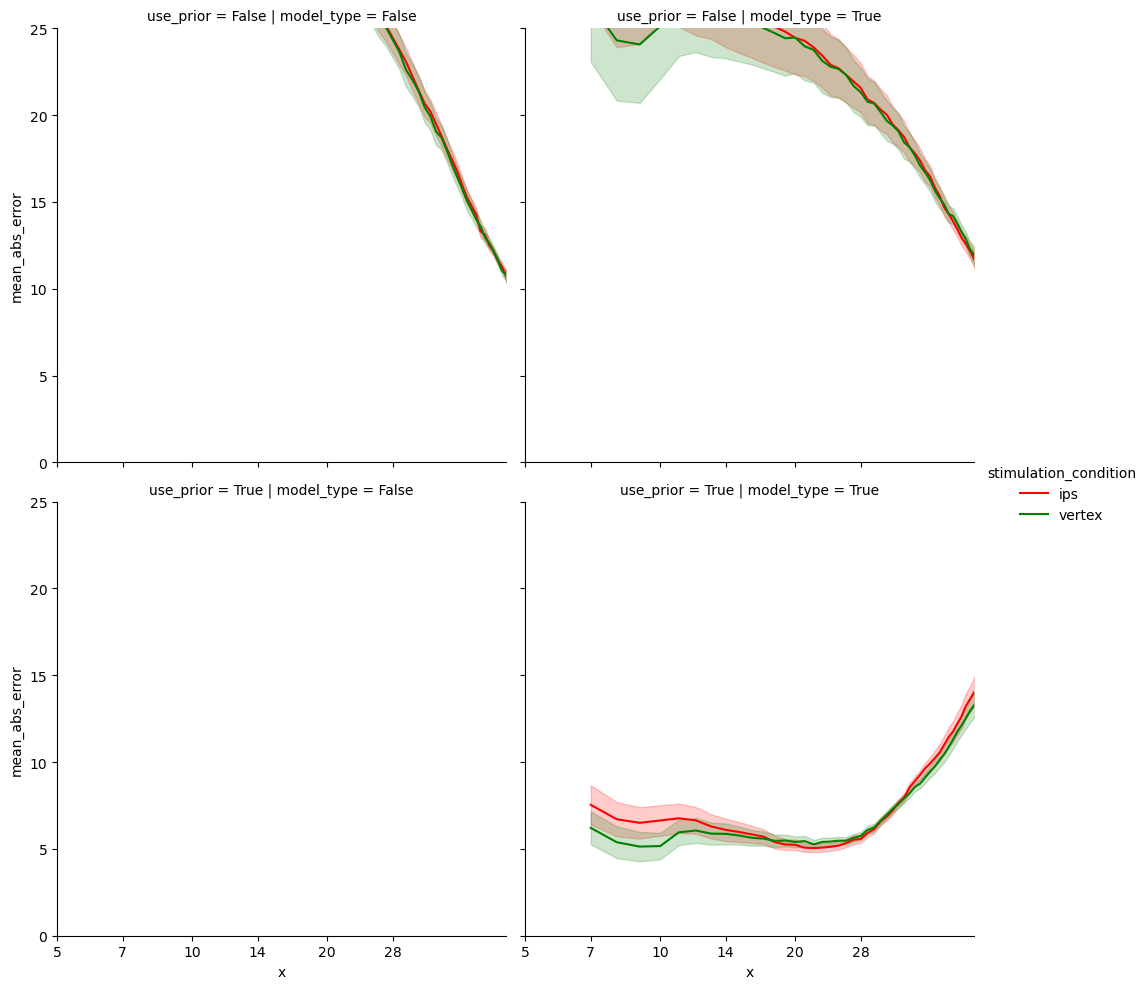

In [8]:
tmp = df.groupby(['subject', 'stimulation_condition', 'x', 'model_type', 'use_prior']).mean()

plt.figure()
sns.relplot(x='x', y='mean_abs_error', data=tmp.reset_index(), hue='stimulation_condition', row='use_prior', kind='line', palette=['red', 'green'], errorbar='se', col='model_type',)
# log x-scale
plt.xscale('log')

# xticks on 5,7,10,14,20,28
plt.xlim(5, 50)
plt.ylim(0, 25)
plt.xticks([5, 7, 10, 14, 20, 28], [5, 7, 10, 14, 20, 28])

# remove mino ticks
plt.minorticks_off()

In [9]:

df['sd_E'] = np.sqrt(df['var_E'])

<Figure size 640x480 with 0 Axes>

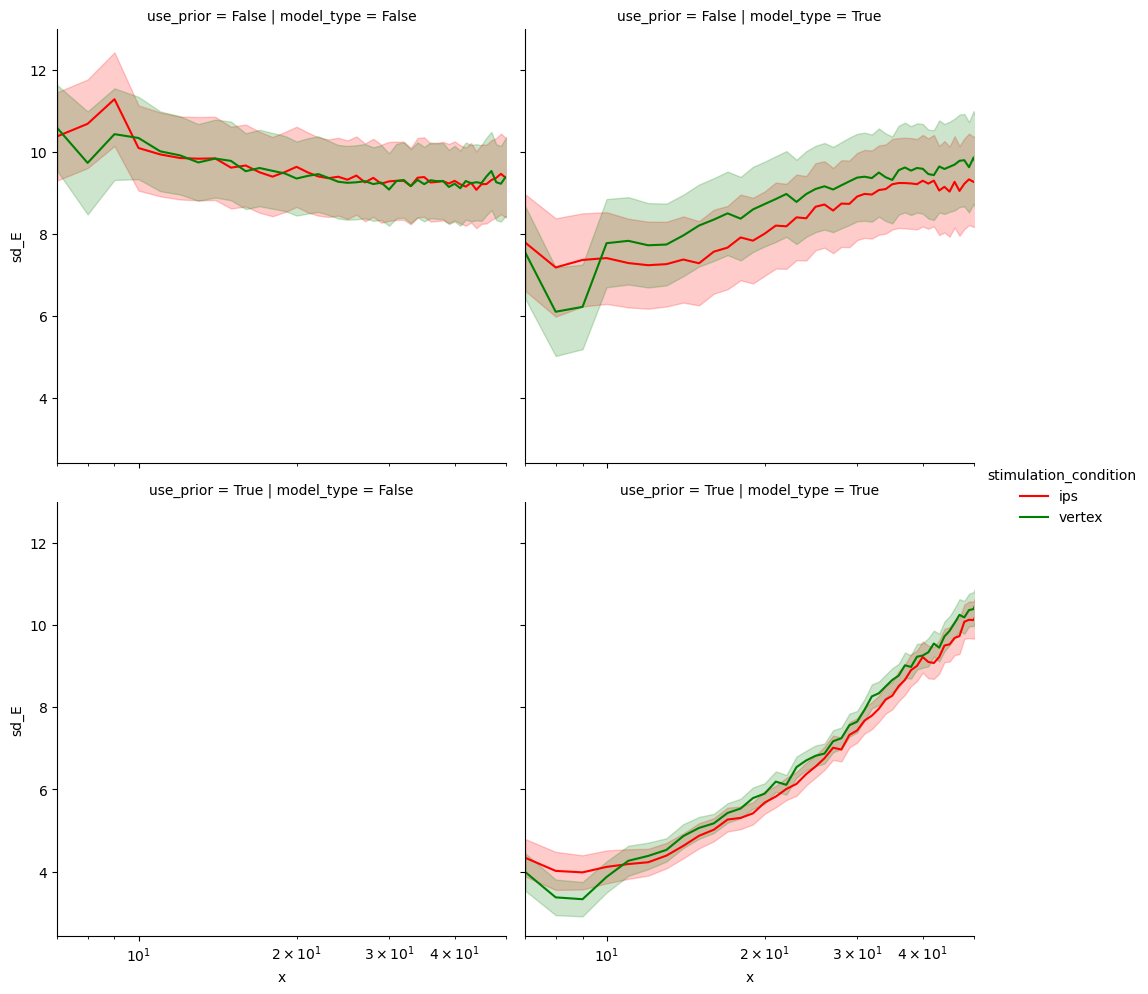

In [10]:
tmp = df.groupby(['subject', 'stimulation_condition', 'model_type', 'use_prior', 'x']).mean()


plt.figure()
sns.relplot(x='x', y='sd_E', data=tmp.reset_index(), hue='stimulation_condition', kind='line', palette=['red', 'green'], errorbar='se', col='model_type', row='use_prior')
plt.xlim(7, 50)
# log x-scale
plt.xscale('log')

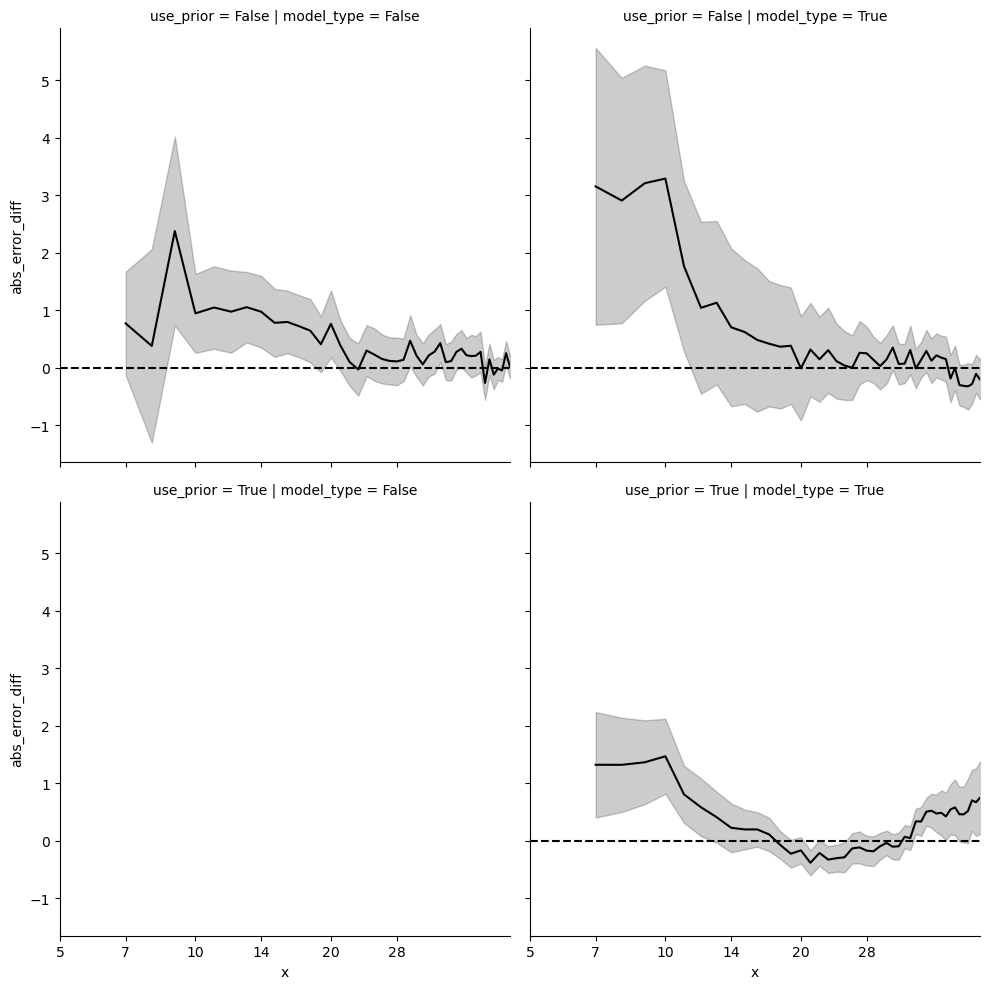

In [11]:
diff = tmp['mean_abs_error'].unstack('stimulation_condition')
diff = (diff['ips'] - diff['vertex']).to_frame('abs_error_diff')

g = sns.relplot(x='x', y='abs_error_diff', data=diff.reset_index(), kind='line', errorbar='se', color='k', col='model_type', row='use_prior')
g.map(plt.axhline, y=0, color='k', linestyle='--')

# log x-scale
plt.xscale('log')


# ticks
plt.xlim(5, 50)
plt.xticks([5, 7, 10, 14, 20, 28], [5, 7, 10, 14, 20, 28])
# remove mino ticks
plt.minorticks_off()

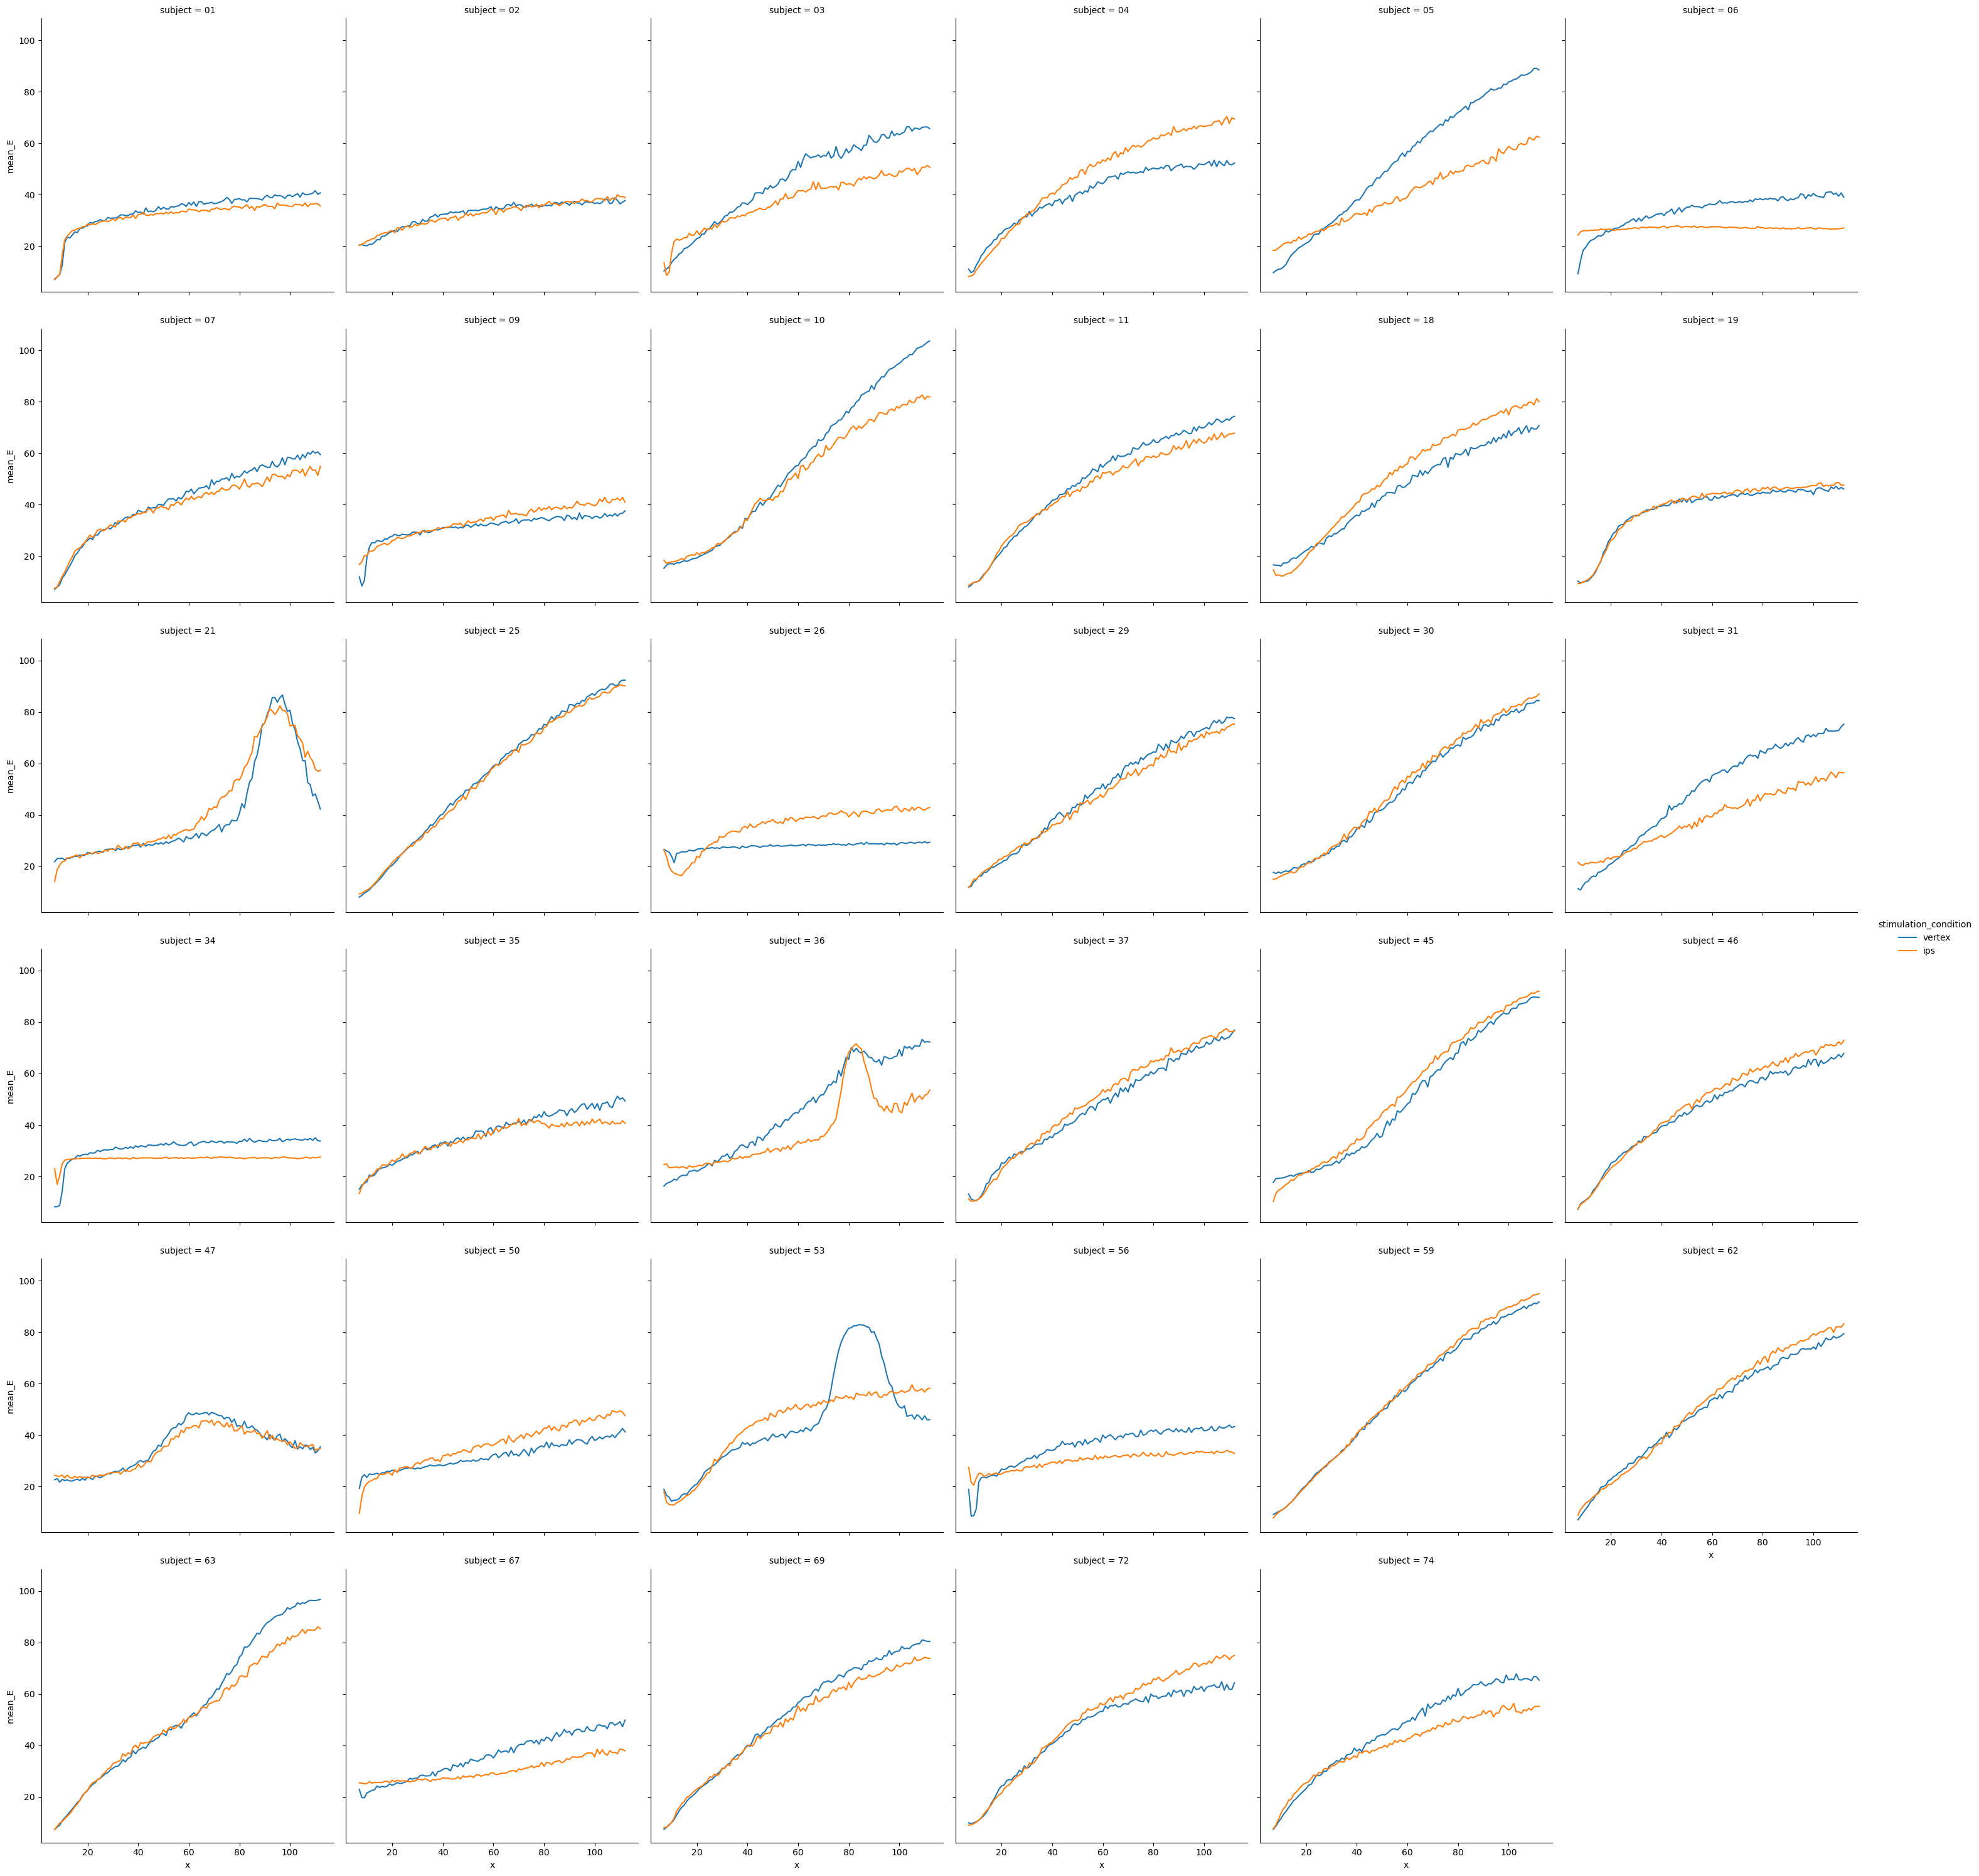

In [12]:
sns.relplot(data=df.xs(True, level='use_prior').reset_index(), x='x', y='mean_E', col='subject', col_wrap=6, kind='line', hue='stimulation_condition')

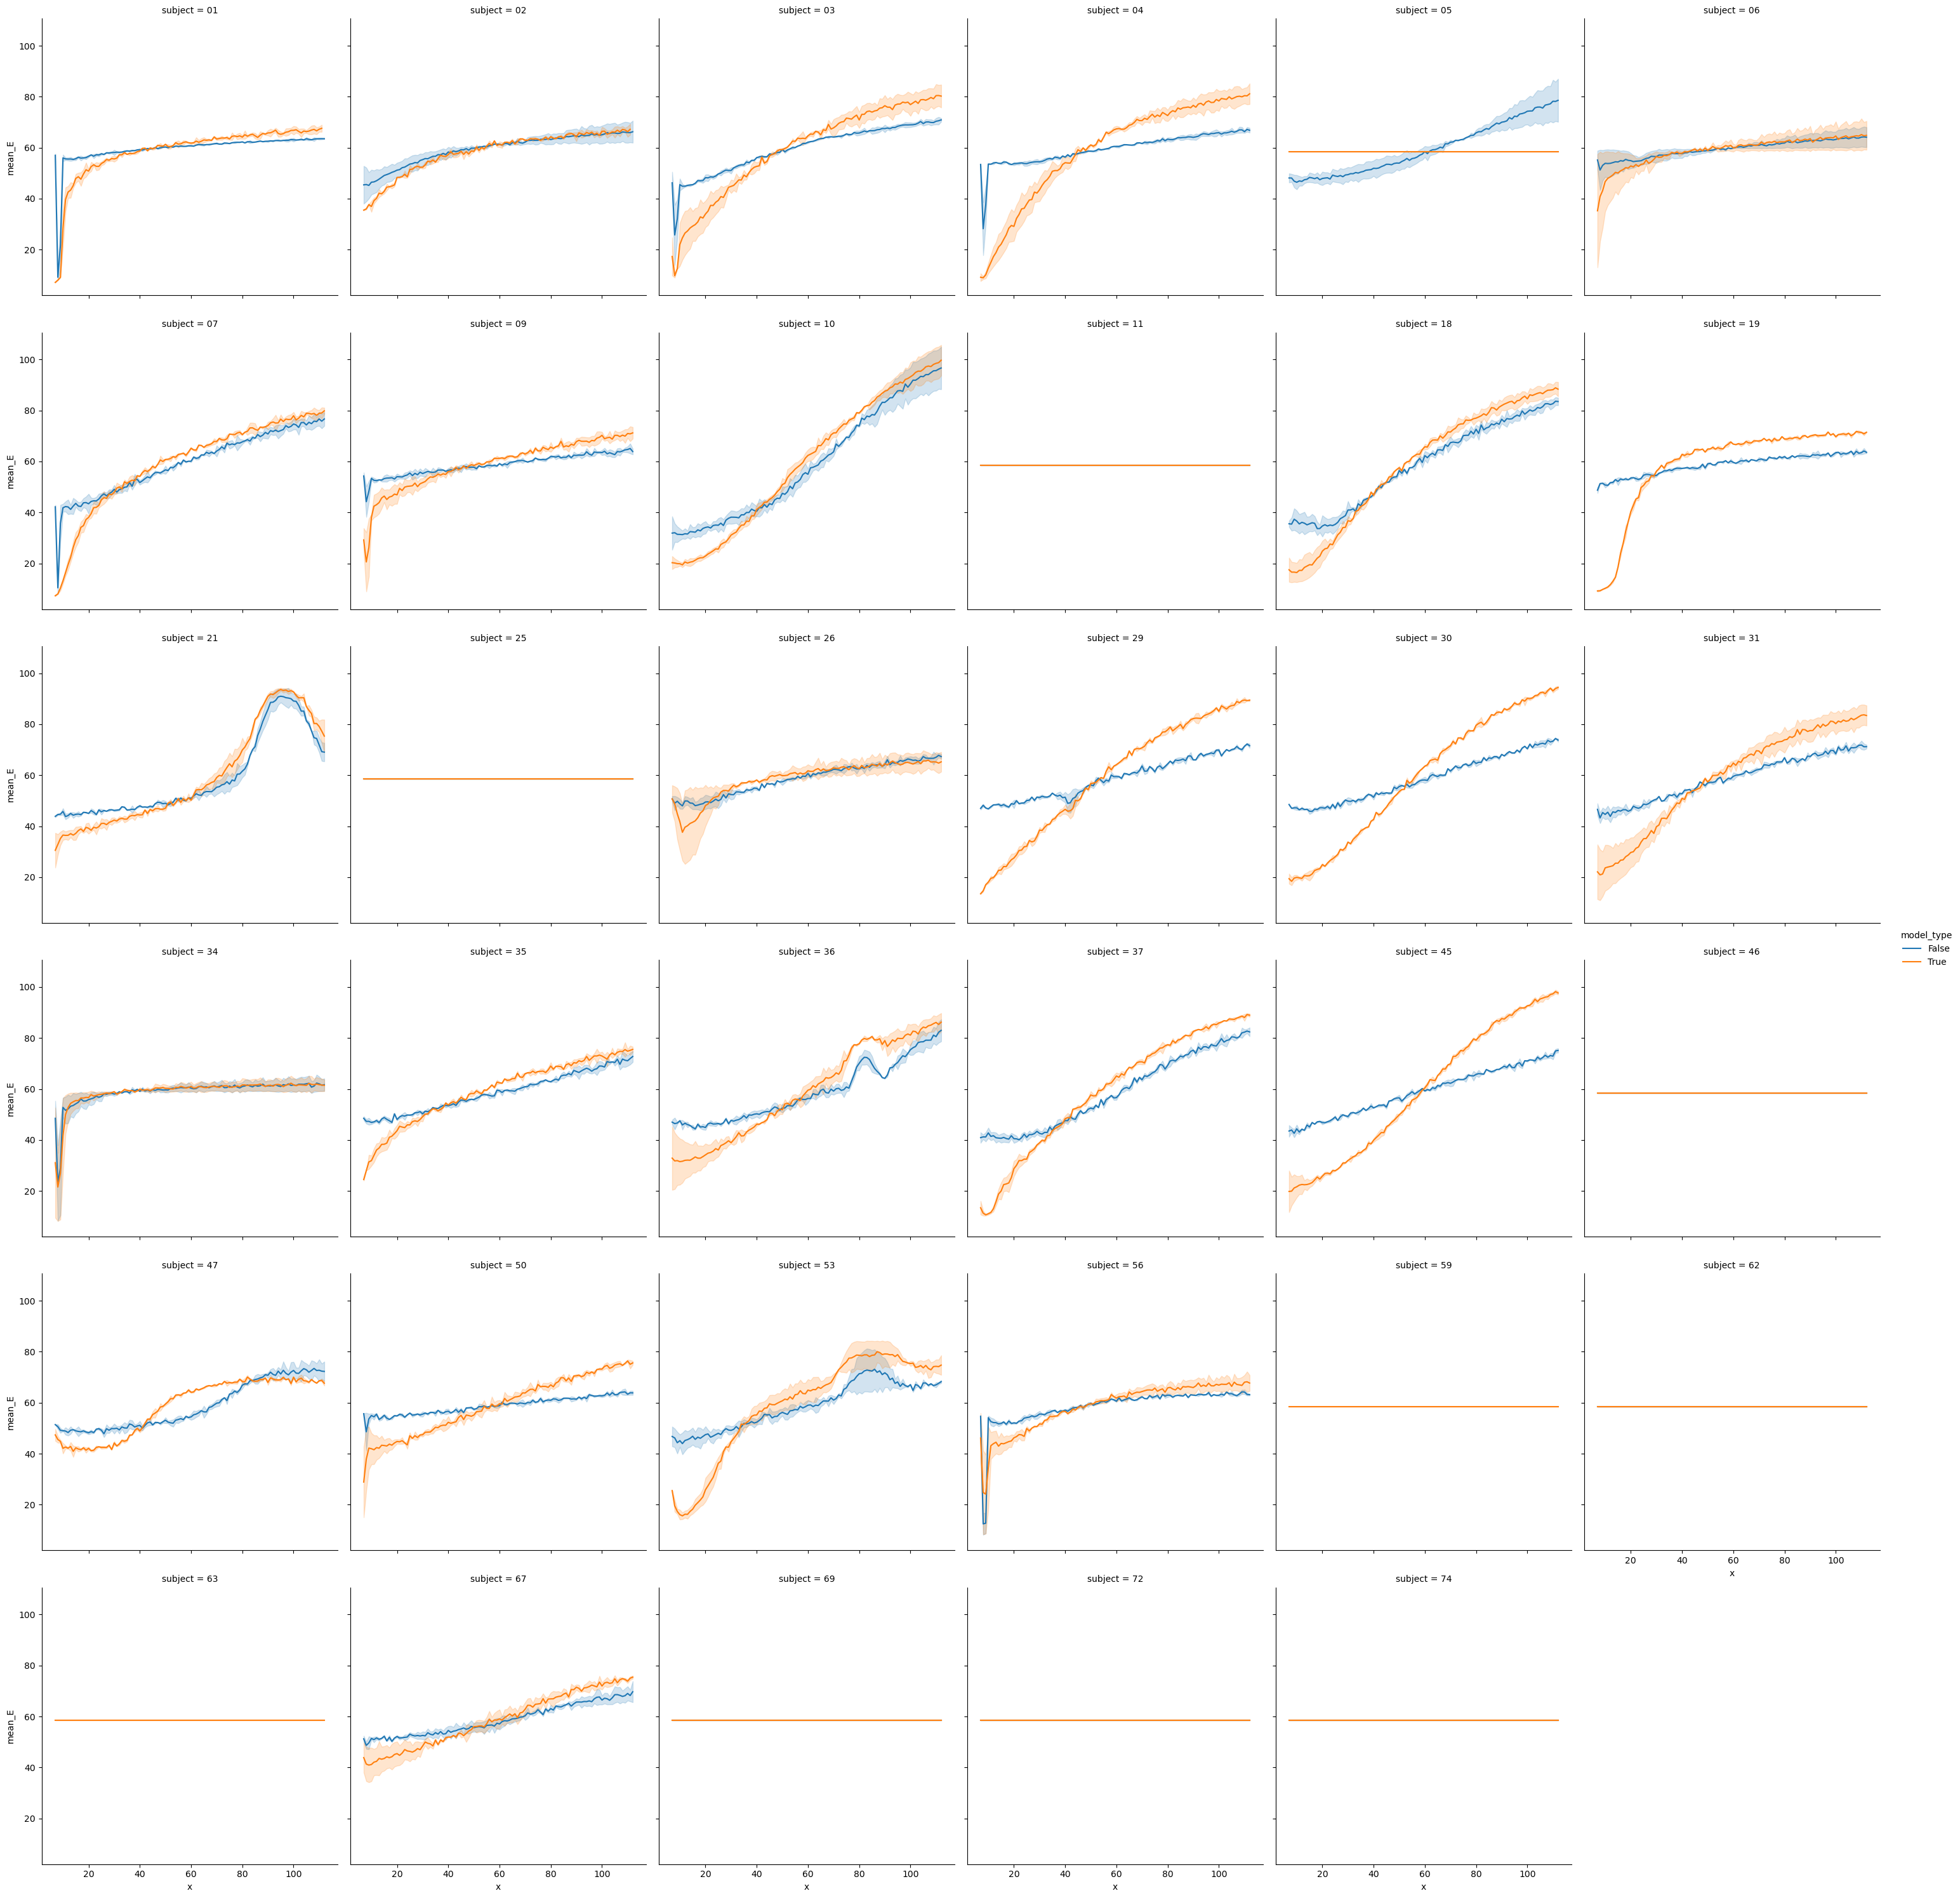

In [13]:
sns.relplot(data=df.xs(False, level='use_prior').reset_index(), x='x', y='mean_E', col='subject', col_wrap=6, kind='line', hue='model_type')

In [14]:
import numpy as np
import pandas as pd
import mne
from mne.stats import permutation_cluster_1samp_test

alpha = 0.05
n_permutations = 5000  # increase if needed

def cluster_test_subject_diff(tmp_df, model_type, use_prior):
    # Filter to one combination
    df_combo = tmp_df.xs((model_type, use_prior), level=('model_type','use_prior'))
    # Pivot to get subject×x for each condition
    ips = df_combo.xs('ips', level='stimulation_condition')['mean_abs_error'].unstack('x')
    vertex = df_combo.xs('vertex', level='stimulation_condition')['mean_abs_error'].unstack('x')
    # Align subjects and x
    ips, vertex = ips.align(vertex, join='inner', axis=0)
    ips, vertex = ips.align(vertex, join='inner', axis=1)
    # Subject-by-x difference
    X = (ips.values - vertex.values)  # shape: (n_subjects, n_times)
    times = ips.columns.values        # x-values

    # One-sample test against 0 across subjects for each time point with clustering
    # Tail=0 for two-sided; set threshold=None to use TFCE-like default, or specify a t-threshold
    T_obs, clusters, cluster_p_values, H0 = permutation_cluster_1samp_test(
        X,
        n_permutations=n_permutations,
        tail=0,
        threshold=None,
        out_type='mask',
        buffer_size=None,
        verbose=False
    )

    # Collect significant clusters
    sig = cluster_p_values < alpha
    sig_clusters = [(clusters[i], cluster_p_values[i]) for i in np.where(sig)[0]]

    return T_obs, clusters, cluster_p_values, sig_clusters, times

Using a threshold of 2.032245
stat_fun(H1): min=-1.7394554465801118 max=2.259899774632761
Running initial clustering …
Found 2 clusters


  0%|          | Permuting : 0/1023 [00:00<?,       ?it/s]

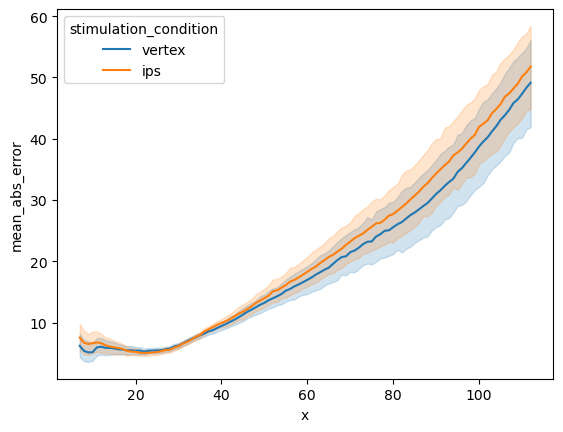

In [15]:
tmp = df.xs(True, level='use_prior').xs(True, level='model_type').droplevel([1]).set_index('x', append=True)[['mean_abs_error']]
sns.lineplot(data=tmp.reset_index(), x='x', y='mean_abs_error', hue='stimulation_condition')

diff = tmp.unstack('stimulation_condition').droplevel(0, axis=1)
diff = diff['ips'] - diff['vertex']

t_obs, clusters, clusters_pv, H0 = permutation_cluster_1samp_test(diff.unstack('x').loc[:, :56])

Using a threshold of 2.032245
stat_fun(H1): min=-1.7012453497860354 max=1.4493843253995795
Running initial clustering …
Found 0 clusters


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_50259/191095600.py:7: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  t_obs, clusters, clusters_pv, H0 = permutation_cluster_1samp_test(diff.unstack('x').loc[:, :56])


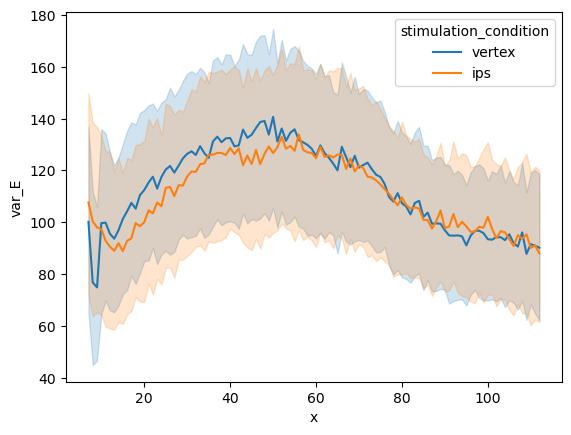

In [16]:
tmp = df.xs(False, level='use_prior').xs(True, level='model_type').droplevel([1]).set_index('x', append=True)[['var_E']]
sns.lineplot(data=tmp.reset_index(), x='x', y='var_E', hue='stimulation_condition')

diff = tmp.unstack('stimulation_condition').droplevel(0, axis=1)
diff = diff['ips'] - diff['vertex']

t_obs, clusters, clusters_pv, H0 = permutation_cluster_1samp_test(diff.unstack('x').loc[:, :56])

In [29]:
import pingouin as pg
df.xs(True, level='use_prior').xs(True, level='model_type').droplevel([1]).set_index('x', append=True)[['mean_abs_error']]

# only between 7 and 20
tmp = df.xs(True, level='use_prior').xs(True, level='model_type').droplevel([1]).set_index('x', append=True)[['mean_abs_error']]
tmp = tmp[(tmp.index.get_level_values('x') >= 7) & (tmp.index.get_level_values('x') <= 20)]


diff = tmp.groupby(['subject', 'stimulation_condition']).mean().unstack('stimulation_condition').droplevel(0, axis=1)

pg.ttest(diff['ips'], diff['vertex'], paired=True)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,1.41207,34,two-sided,0.167017,"[-0.24, 1.32]",0.165984,0.449,0.159101
